In [2]:
#General imports
resol = 300
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
pi = np.pi
from pathlib import Path

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports

from src.xp_config import ExperimentConfig
from src.experiment import Experiment
from src.rg_integrator import rg_propagator

Physical parameters and frequency window

In [3]:
omega_A = 10*pi
Gamma = 10*pi

lbda = 10*pi
cutoffs = {'ir_cutoff': omega_A - lbda, 'uv_cutoff': omega_A + lbda}

Prepare a beamsplitter experiment with the parameterization from single photon paper

In [4]:
L = 50

param_cavity = {'omega_0': omega_A, 'gamma': Gamma / (1 + Gamma / (pi*lbda)), 'L': L}

param_time_evol = {'T': L/2, 'dt': 0.01}

param_photons = {'omega_p': [omega_A - Gamma/2, omega_A - Gamma/2 ], 
                 'delta_k': [0.05*pi, 0.05*pi],
                 'x_0': [-L/4, -L/4]}

#some tests
ratio1 = param_cavity['gamma'] / (param_cavity['omega_0'] - cutoffs['ir_cutoff'])
ratio2 = param_cavity['gamma'] / (param_cavity['omega_0'] - cutoffs['ir_cutoff'])**2

print("Ratio1 =", ratio1)
print("Ratio2 =", ratio2)

Ratio1 = 0.7585469929947761
Ratio2 = 0.024145300700522385


Run the experiment

In [4]:
config = ExperimentConfig(param_photons, param_cavity, param_time_evol, cutoffs)
scattering_experiment = Experiment(config)
c_array, b1_array, b2_array = scattering_experiment.propagate_state(progress=True)

#Check eventual messages
messages = scattering_experiment.get_messages()

100%|██████████| 2499/2499 [02:05<00:00, 19.91it/s]


Get the observables

In [5]:
time_array = np.arange(0, param_time_evol['T'], param_time_evol['dt'])   
#Compute observables
An_array, P11n_array, P12n_array, P21n_array, P22n_array = scattering_experiment.compute_observables(progress=True)
#Check eventual messages
messages = scattering_experiment.get_messages()

100%|██████████| 2500/2500 [02:43<00:00, 15.25it/s]


Anti HOM probability: 0.004994465725146537


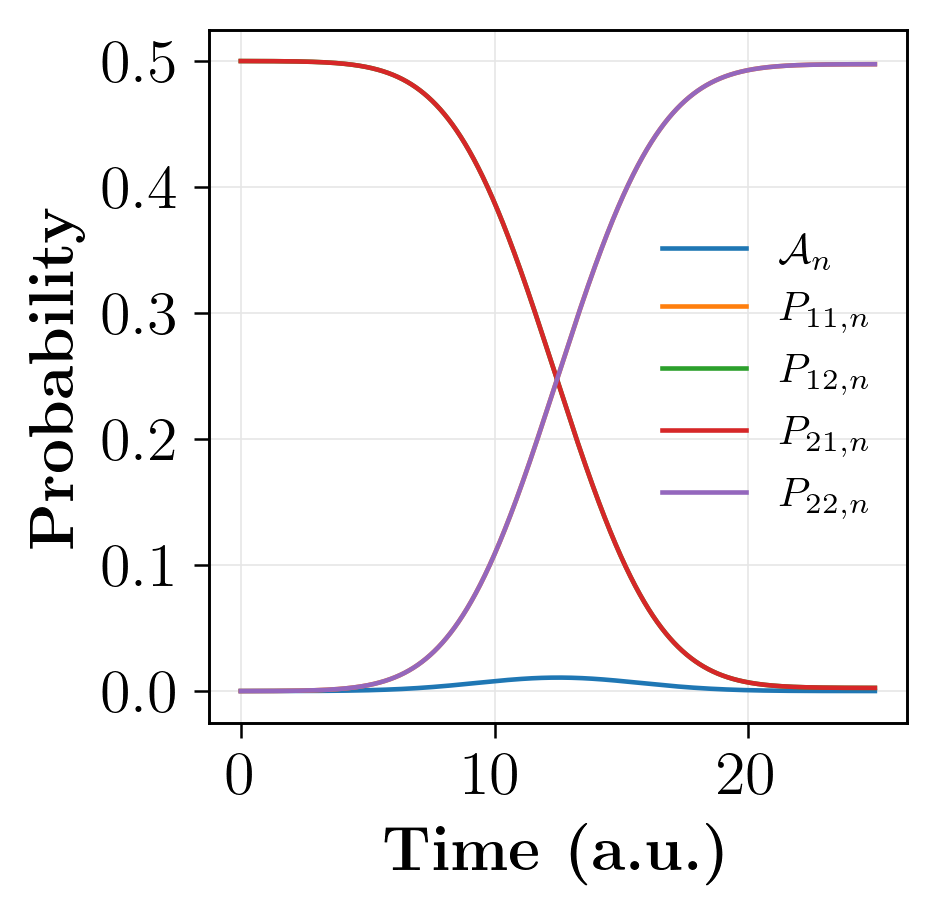

: 

In [ ]:
print("Anti HOM probability:", P12n_array[-1] + P21n_array[-1])

fig, ax = plt.subplots(figsize=(3, 3), dpi=300)

step_marker = 100  


# ---- courbes lisses ----
ax.plot(time_array, An_array, '-', lw=1.1, label=r'$\mathcal{A}_n$')
ax.plot(time_array, P11n_array, '-', lw=1.1, label=r'$P_{11,n}$')
ax.plot(time_array, P12n_array, '-', lw=1.1, label=r'$P_{12,n}$')
ax.plot(time_array, P21n_array, '-', lw=1.1, label=r'$P_{21,n}$')
ax.plot(time_array, P22n_array, '-', lw=1.1, label=r'$P_{22,n}$')


# Labels, limites et grille
ax.set_xlabel(r'\textbf{Time (a.u.)}', fontsize=10)
ax.set_ylabel(r'\textbf{Probability}', fontsize=10)
ax.grid(color='0.9', linestyle='-', linewidth=0.4)

# Légende sobre
ax.legend(prop={'size': 10}, loc="best", frameon=False)

#font size
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(15)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(15)

plt.show()